In [1]:
!pip install -U langchain langchain-core langgraph langchain-google-genai python-dotenv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.6/139.6 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.7/561.7 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.8/247.8 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 kB 4.1 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.4.9
    Uninstalling langchain-core-1.4.9:
      Successfully uninstalled langchain-core-1.4.9
  Attempting uninstall: langgraph
    Found existing installation: langgraph 1.2.9
    Uninstalling langgraph-1.2.9:
      Successfully uninstalled langgraph-1.2.9
  Attempting uninstall: langchain
    Found existing installation: langchain 1.3.13
    Uninstalling langchain-1.3.13:
      Successfully uninstalled langchain-1.3.13


In [2]:
from typing import TypedDict, Annotated

from langchain_google_genai import ChatGoogleGenerativeAI

from langchain_core.messages import (
    AnyMessage,
    AIMessage,
    BaseMessage
)

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

from langgraph.checkpoint.memory import MemorySaver

from langgraph.types import interrupt, Command

from dotenv import load_dotenv

In [10]:
llm=ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [11]:
load_dotenv()

True

In [12]:
from langgraph.graph.message import add_messages
class ChatState(TypedDict):
  messages:Annotated[list[BaseMessage],add_messages]

In [14]:
def chat_node(state:ChatState):
  decision=interrupt({

          "type":"approval",
          "reason":"Model is about to answer a question",
          "question":state["messages"][-1].content,
          "instruction":"Approve this question?yes/no"

  }
)
  if decision["approved"]=="no":
    return {"messages":[AIMessage(content="Not approved")]}
  else:
    response=llm.invoke(state["messages"])
    return {"messages":[response]}

In [16]:
builder=StateGraph(ChatState)
builder.add_node("chat",chat_node)
builder.add_edge(START,"chat")
builder.add_edge("chat",END)

checkpointer=MemorySaver()

app=builder.compile(checkpointer=checkpointer)

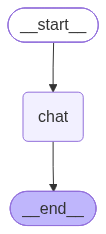

In [17]:
app

In [19]:
config = {
    "configurable": {
        "thread_id": "1234"
    }
}

initial_input = {
    "messages": [
        ("user", "Explain gradient descent in very simple terms")
    ]
}

result = app.invoke(
    initial_input,
    config=config
)

print(result)

{'messages': [HumanMessage(content='Explain gradient descent in very simple terms', additional_kwargs={}, response_metadata={}, id='3291617c-ac23-4bf6-a090-9b86a2ecb89b')], '__interrupt__': [Interrupt(value={'type': 'approval', 'reason': 'Model is about to answer a question', 'question': 'Explain gradient descent in very simple terms', 'instruction': 'Approve this question?yes/no'}, id='358ed534b5286fbfc16b2a21c2c1d2b4')]}


In [21]:
message=result['__interrupt__'][0].value
message

{'type': 'approval',
 'reason': 'Model is about to answer a question',
 'question': 'Explain gradient descent in very simple terms',
 'instruction': 'Approve this question?yes/no'}

In [24]:
user_input=input(f"\nBackend message-{message} \n Approve this question? (y/n)")


Backend message-{'type': 'approval', 'reason': 'Model is about to answer a question', 'question': 'Explain gradient descent in very simple terms', 'instruction': 'Approve this question?yes/no'} 
 Approve this question? (y/n)y


In [29]:
from langgraph.types import Command

final_result = app.invoke(
    Command(resume={"approved": user_input}),
    config=config
)

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash' (NOT_FOUND): 404 NOT_FOUND. {'error': {'code': 404, 'message': 'This model models/gemini-2.5-flash is no longer available to new users. Please update your code to use a newer model for the latest features and improvements. We recommend you to use the Interactions API (https://ai.google.dev/gemini-api/docs/migrate-to-interactions).', 'status': 'NOT_FOUND'}}